### Imports

In [1]:
import torch
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

from transformer_lens import HookedTransformer
from huggingface_hub import login
from dotenv import load_dotenv

import os
import random
import re

/Users/dgutu/Programming/University/LLM-Interpretability/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ["TRANSFORMERLENS_ALLOW_MPS"] = "1"

In [3]:
load_dotenv()
login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
models = [
    "pythia-70m",
    "gpt2-small",
    "gpt2-medium",
    "gemma-2b",
]

In [39]:
device = "mps" if torch.mps.is_available() else "cpu"
model_name = models[0]

print(f"Model {model_name} on {device}...")

Model pythia-70m on mps...


In [40]:
model = HookedTransformer.from_pretrained(model_name, device=device)

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████| 76/76 [00:00<00:00, 1102.40it/s]


Loaded pretrained model pythia-70m into HookedTransformer


In [41]:
# torch.save({
#     'state_dict': model.state_dict(),
#     'cfg': model.cfg
# }, "hooked_model_cache.pt")

In [42]:
# checkpoint = torch.load("hooked_model_cache.pt")
# # Reconstruct using the saved config
# model = HookedTransformer(checkpoint['cfg'])
# model.load_state_dict(checkpoint['state_dict'])
# model.to(device)

# model = HookedTransformer.from_pretrained(
#     model_name, 
#     device=device, 
#     hf_model=None, # Prevents re-fetching metadata
# )

### Utils

In [43]:
def inject_noise(text, noise_type="markup"):
    """Injects specific types of noise to test layer robustness."""
    if noise_type == "markup":
        tags = ["<div>", "<b>", "<span>", "<p>"]
        tag = random.choice(tags)
        return f"{tag}{text}{tag.replace('<', '</')}"

    elif noise_type == "symbols":
        syms = ["!!!", "@@@", "***", "###"]
        s = random.choice(syms)
        return f"{s} {text} {s}"

    elif noise_type == "marketing":
        phrases = ["[BEST SELLER]", "[LIMITED TIME]", "FREE SHIPPING!", "100% GENUINE"]
        return f"{random.choice(phrases)} {text}"
        
    return text

In [44]:
def get_sufficiency_layer(model, prompt, target_token_str, threshold=0.90, min_final_confidence=0.10):
    """
    Calculates L_suff: The earliest layer where the target token's probability 
    reaches the threshold % of its final layer probability.
    """
    # 1. Get the single token ID for the target
    # try:
    #     target_token_id = model.to_single_token(target_token_str)
    # except Exception as e:
    #     print("Broken string", e)
    #     # If the target string breaks into multiple tokens, this skips it for simplicity
    #     return None, 0.0, False 
    tokens = model.to_tokens(target_token_str, prepend_bos=False)
    if tokens.shape[-1] > 1:
        # Use the first token of the target word for the analysis
        target_token_id = tokens[0, 0].item() 
    else:
        target_token_id = tokens.item()

    # 2. Run cache
    logits, cache = model.run_with_cache(prompt)
    
    # 3. Extract accumulated residual stream and project to vocabulary
    resid_stack = cache.accumulated_resid(incl_mid=False)
    final_pos_resid = resid_stack[:, 0, -1, :] 
    layer_logits = model.unembed(model.ln_final(final_pos_resid))
    layer_probs = torch.softmax(layer_logits, dim=-1)
    
    # 4. Extract probability trajectory for the specific target
    target_probs = layer_probs[:, target_token_id].detach().cpu().numpy()
    final_prob = target_probs[-1]
    
    # 5. Success Check: Did the model actually solve the task at the end?
    if final_prob < min_final_confidence:
        # print("Model failed the task: ", final_prob)
        return None, final_prob, False # Model failed the task, discard this sample
        
    # 6. Calculate L_suff
    target_threshold = threshold * final_prob
    l_suff = len(target_probs) - 1 # Default to final layer
    
    for layer_idx, prob in enumerate(target_probs):
        if prob >= target_threshold:
            l_suff = layer_idx
            break
    
    # print("Model successfully completed the task: ", prob)
    return l_suff, final_prob, True, 

In [45]:
def run_experiment(model, df, sample, threshold):
    print("Loading dataset...")

    try:
        raw_products = df["product_name"].dropna().unique().tolist()[:200]
    except FileNotFoundError:
        print("CSV not found. Generating synthetic dataset for demonstration...")
        raw_products = [
            "Adidas Ultraboost 22", "Sony PlayStation 5", "Apple iPhone 14",
            "Samsung Galaxy S23", "Nike Air Max", "Logitech MX Master 3",
            "Bose QuietComfort 45", "Dell XPS 13", "Nintendo Switch OLED",
            "Dyson V15 Detect"
        ]

    results = []
    noise_categories = ["markup", "symbols", "marketing"]
    
    print(f"Starting batch processing across {len(raw_products)} samples...")
    with torch.no_grad():
      for category in noise_categories:
          print(f"Processing category: {category}")
          success_count = 0
          
          for original in raw_products:
              # Generate the dirty input
              noisy_input = inject_noise(original, category)
              
              # The target is the first main token of the original product name
              # Prepend a space because tokenization usually includes leading spaces
              target_token_str = " " + original.split()[0] 
              
              # Few-shot prompt to force the model into extraction mode
              prompt = (
                  "Task: Extract the core brand name.\n"
                  "**Example:** Input: <p>NIKE shoes cheap</p> | Clean: Nike\n"
                  f"Input: {noisy_input} | Clean:"
              )
              
              l_suff, final_prob, is_success = get_sufficiency_layer(
                  model, 
                  prompt, 
                  target_token_str, 
                  threshold=threshold
              )
              
              if is_success:
                  results.append({
                      "Original": original,
                      "Noisy_Input": noisy_input,
                      "Target_Token": target_token_str,
                      "Noise_Category": category,
                      "L_suff": l_suff,
                      "Final_Confidence": final_prob
                  })
                  success_count += 1
                  
          print(f"  -> Successfully evaluated {success_count}/{len(raw_products)} samples.")

    if not results:
        print("No successful evaluations to plot. Check your prompt or target tokens.")
        return

    results_df = pd.DataFrame(results)
    
    # Save to CSV for your article's appendix or further analysis
    results_df.to_csv(f"../data/03-results/layer_sufficiency_results_{model_name}_{sample}_{threshold}.csv", index=False)
    print("\nResults saved to 'layer_sufficiency_results.csv'")
    
    # Generate the Interactive Plotly Chart
    fig = px.box(
        results_df, 
        x="Noise_Category", 
        y="L_suff", 
        color="Noise_Category",
        title="Computational Depth Required per Noise Type (Layer Sufficiency)",
        labels={
            "Noise_Category": "Type of Injected Noise",
            "L_suff": "Sufficiency Layer (L_suff) at 90% Confidence"
        },
        template="plotly_white",
        points="all" # Shows individual data points alongside the box
    )
    
    fig.update_layout(
        yaxis=dict(tickmode='linear', tick0=0, dtick=1)
    )
    
    fig.show()

### Dataset Load

In [46]:
df = pd.read_csv("../data/02-processed/features.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   product_id          1465 non-null   str  
 1   product_brand       1465 non-null   str  
 2   product_name        1465 non-null   str  
 3   noisy_product_name  1465 non-null   str  
dtypes: str(4)
memory usage: 457.4 KB


In [47]:
df.head(1)

,product_id,product_brand,product_name,noisy_product_name
0,B07JW9H4J1,Wayona,Wayona Nylon Braided USB to Lightning Fast Cha...,[LIMITED TIME] Wayona Nylon Braided USB to Lig...


### LLM Layers Analysis

In [48]:
sample = 100
sample_df = df.sample(n=sample, random_state=42).reset_index(drop=True)
threshold = 0.9

In [49]:
prompt = "[BEST SELLER] Acer 139 cm (55 inches) H Series 4K Ultra HD Android Smart LED TV AR55AR2851UDPRO (Black). Cleaned Name:"

tokens = model.to_tokens(prompt)
str_tokens = model.to_str_tokens(tokens[0])

In [50]:
# Run the model and cache ALL internal activations
# run_with_cache returns the final logits and a Cache object containing every tensor
logits, cache = model.run_with_cache(prompt)

In [51]:
# 4. The Logit Lens Core Logic
# We extract the accumulated residual stream across all layers.
# This tells us the "state of the sequence" after each transformer block.
resid_stack, labels = cache.accumulated_resid(
    incl_mid=False, # We just want the output of each block, not the mid-MLP states
    return_labels=True
)

# We only care about the representation at the FINAL token's position,
# because this is where the model is predicting the very first token of the "Cleaned Name".
# resid_stack shape: [num_layers, batch, seq_len, d_model]
final_token_resid = resid_stack[:, 0, -1, :] # Shape: [num_layers, d_model]

# Project these intermediate representations into the vocabulary space.
# We mimic the end of the network: apply the final LayerNorm, then multiply by the Unembedding matrix.
layer_logits = model.unembed(model.ln_final(final_token_resid)) # Shape: [num_layers, d_vocab]

# Convert raw logits to probabilities
layer_probs = torch.softmax(layer_logits, dim=-1)

In [52]:
final_layer_probs = layer_probs[-1]
top_tokens_indices = final_layer_probs.topk(10).indices

print("\nTop 5 predictions at the final layer:")
for idx in top_tokens_indices:
    print(f"'{model.to_string(idx)}': {final_layer_probs[idx]:.4f}")


Top 5 predictions at the final layer:
' A': 0.0164
' Black': 0.0124
' C': 0.0110
'
': 0.0086
' S': 0.0083
' B': 0.0079
' The': 0.0075
' O': 0.0071
' [': 0.0063
' T': 0.0061


In [53]:
data = []
for layer_idx, label in enumerate(labels):
    for token_idx in top_tokens_indices:
        token_str = model.to_string(token_idx)
        prob = layer_probs[layer_idx, token_idx].item()
        data.append({
            "Layer": label,
            "Token": token_str,
            "Probability": prob,
            "Layer_Num": layer_idx
        })

df = pd.DataFrame(data)

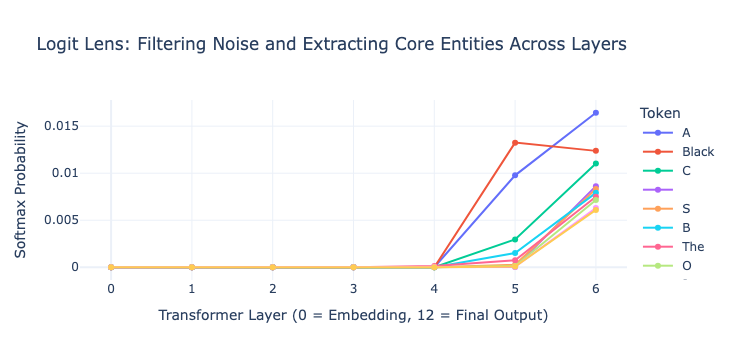

In [54]:
# Generate Interactive Plotly Chart
fig = px.line(
    df,
    x="Layer_Num",
    y="Probability",
    color="Token",
    title="Logit Lens: Filtering Noise and Extracting Core Entities Across Layers",
    labels={
        "Layer_Num": "Transformer Layer (0 = Embedding, 12 = Final Output)",
        "Probability": "Softmax Probability"
    },
    markers=True,
    template="plotly_white"
)

fig.update_layout(
    xaxis=dict(tickmode='linear', tick0=0, dtick=1),
    hovermode="x unified"
)

# Renders the interactive widget in Colab
fig.show()

Loading dataset...
Starting batch processing across 100 samples...
Processing category: markup
  -> Successfully evaluated 0/100 samples.
Processing category: symbols
  -> Successfully evaluated 1/100 samples.
Processing category: marketing
  -> Successfully evaluated 0/100 samples.

Results saved to 'layer_sufficiency_results.csv'


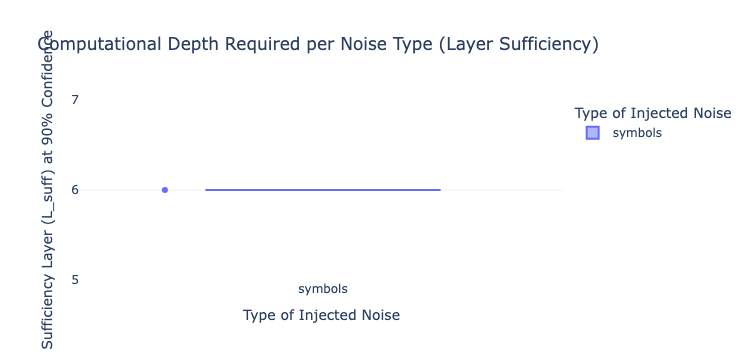

In [55]:
run_experiment(model, sample_df, sample, threshold)